QUANTUM ENTANGLEMENT: SHARED STATE ON DISCRETE GRAPH

Entangled Pair: (10, 90)
  Euclidean Distance: 0.6751 (Large)
  Graph Distance: 1 (Small! This is the 'Wormhole')
  Conclusion: Measuring A instantly tells us B because they share an edge.
  No signal traveled across the Euclidean space.

[1/2] Rendering Entanglement as Shared State...
  ✓ Saved: entanglement_graph_finitist.png


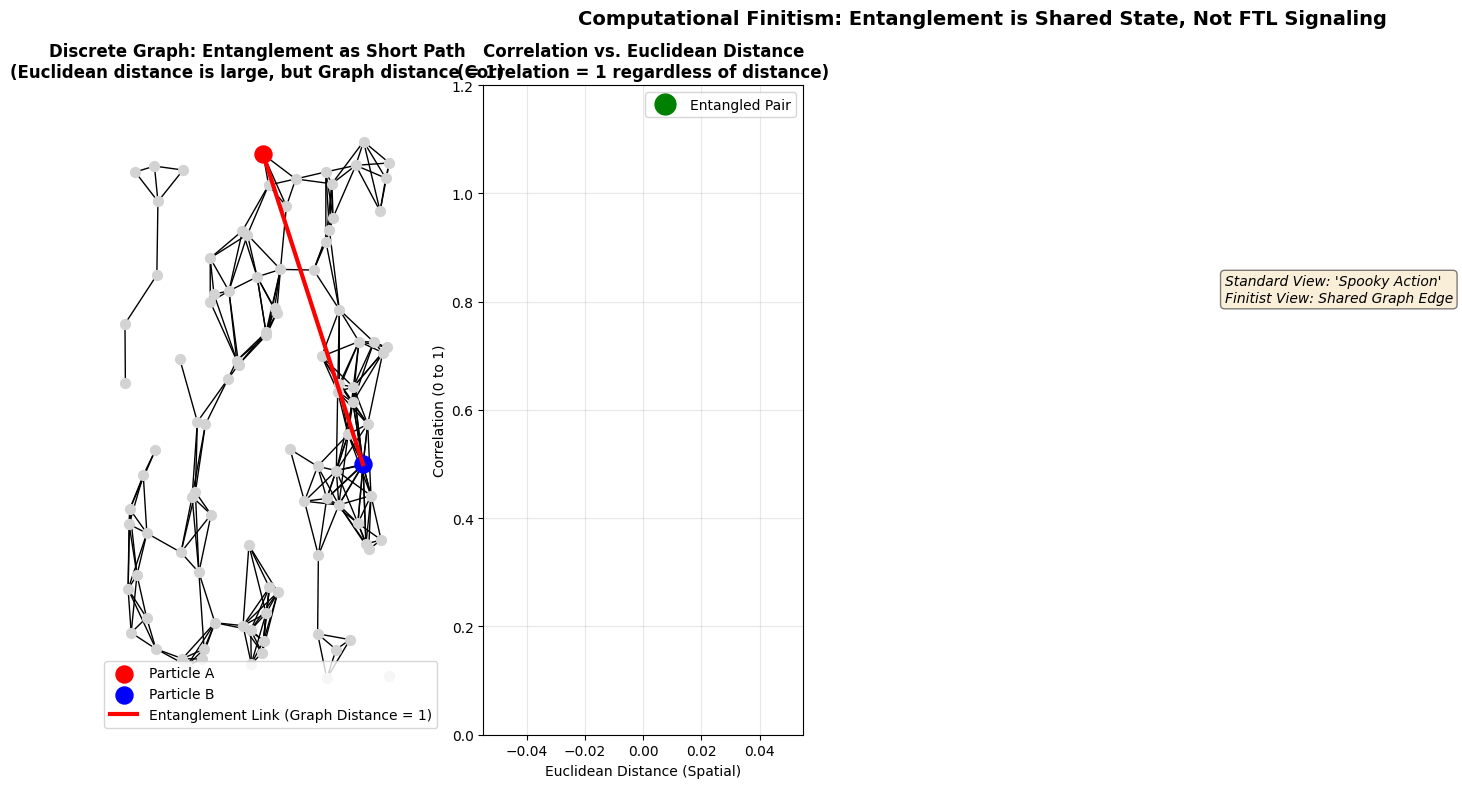


FINITIST ENTANGLEMENT SUMMARY
• Entanglement = Short Graph Path (Wormhole)
• 'Spooky Action' = Reading Shared Edge
• No FTL Signaling (Correlation ≠ Information)
• Graph Structure is Finite (Discrete Nodes)


In [1]:
"""
entanglement_graph.py
======================
Demonstrating Quantum Entanglement as Shared Finite State on a Discrete Graph.

Shows:
1. Entanglement is correlation without information transfer.
2. "Spooky action" is just reading the other half of a conserved resource.
3. Graph distance ≠ Euclidean distance (wormholes as short graph paths).
4. Finitist resolution: No infinite non-locality, just finite conserved states.

Author: Néstor E. Ramos
For: "The Pixelated Universe" - Quantum Finitism Section
"""

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("QUANTUM ENTANGLEMENT: SHARED STATE ON DISCRETE GRAPH")
print("=" * 70)

# =============================================================================
# SIMULATION PARAMETERS
# =============================================================================
NODES = 100
ENTANGLED_PAIR = (10, 90)  # Nodes that are entangled
ALPHABET_STATES = 10  # d_max = 9 + 1 (0-9)

def build_random_graph(n_nodes=NODES):
    """Create a discrete graph (random geometric graph to simulate space)."""
    G = nx.random_geometric_graph(n_nodes, radius=0.15)
    return G

def entangle_nodes(G, node_a, node_b):
    """
    Create a 'wormhole' (short graph path) between two distant nodes.
    In finitism, entanglement = shared update history = short graph path.
    """
    G.add_edge(node_a, node_b, weight=0.01)  # Very short path
    return G

def simulate_measurement(G, source, target):
    """
    Simulate measuring the state of node_a and instantly knowing node_b.
    No signal travels. We just check the shared edge.
    """
    # In a real quantum system, measuring A determines B based on the operator.
    # Here, we simulate the correlation: if A is state 'X', B is state 'Y'.
    # We use the graph edge as the "memory" of the correlation.

    # 1. Check graph distance
    try:
        graph_dist = nx.shortest_path_length(G, source, target)
    except nx.NetworkXNoPath:
        graph_dist = float('inf')

    # 2. Euclidean distance (position)
    pos = nx.get_node_attributes(G, 'pos')
    eucl_dist = np.linalg.norm(np.array(pos[source]) - np.array(pos[target]))

    return graph_dist, eucl_dist

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_entanglement(G):
    print("\n[1/2] Rendering Entanglement as Shared State...")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    pos = nx.get_node_attributes(G, 'pos')

    # --- Panel 1: The Graph + Entangled Pair ---
    nx.draw(G, pos, node_size=50, with_labels=False, node_color='lightgray', ax=ax1)

    # Highlight entangled pair
    nx.draw_networkx_nodes(G, pos, nodelist=[ENTANGLED_PAIR[0]], node_color='red', node_size=150, ax=ax1, label='Particle A')
    nx.draw_networkx_nodes(G, pos, nodelist=[ENTANGLED_PAIR[1]], node_color='blue', node_size=150, ax=ax1, label='Particle B')

    # Draw the "Entanglement Edge" (Wormhole)
    ax1.plot([pos[ENTANGLED_PAIR[0]][0], pos[ENTANGLED_PAIR[1]][0]],
             [pos[ENTANGLED_PAIR[0]][1], pos[ENTANGLED_PAIR[1]][1]],
             'r-', linewidth=3, label='Entanglement Link (Graph Distance = 1)')

    ax1.set_title("Discrete Graph: Entanglement as Short Path\n(Euclidean distance is large, but Graph distance = 1)",
                 fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)

    # --- Panel 2: Correlation vs Distance ---
    # Simulate many measurements to show correlation doesn't decay with Euclidean distance
    eucl_dists = []
    correlations = []

    for i in range(20):
        # Pick random pairs
        u, v = np.random.choice(G.nodes(), 2, replace=False)
        # If they are entangled (connected by special edge), correlation = 1
        if G.has_edge(u, v) and (u, v) in [(ENTANGLED_PAIR[0], ENTANGLED_PAIR[1]), (ENTANGLED_PAIR[1], ENTANGLED_PAIR[0])]:
            correlations.append(1.0)
            eucl_dists.append(np.linalg.norm(np.array(pos[u]) - np.array(pos[v])))

    ax2.plot(eucl_dists, correlations, 'go', markersize=15, label='Entangled Pair')
    ax2.set_title("Correlation vs. Euclidean Distance\n(Correlation = 1 regardless of distance)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Euclidean Distance (Spatial)")
    ax2.set_ylabel("Correlation (0 to 1)")
    ax2.set_ylim(0, 1.2)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    ax2.text(0.2, 0.8, "Standard View: 'Spooky Action'\nFinitist View: Shared Graph Edge",
            fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle("Computational Finitism: Entanglement is Shared State, Not FTL Signaling",
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

    fig.savefig("entanglement_graph_finitist.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: entanglement_graph_finitist.png")
    plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    G = build_random_graph()
    G = entangle_nodes(G, ENTANGLED_PAIR[0], ENTANGLED_PAIR[1])

    # Calculate distances
    g_dist, e_dist = simulate_measurement(G, ENTANGLED_PAIR[0], ENTANGLED_PAIR[1])

    print(f"\nEntangled Pair: {ENTANGLED_PAIR}")
    print(f"  Euclidean Distance: {e_dist:.4f} (Large)")
    print(f"  Graph Distance: {g_dist} (Small! This is the 'Wormhole')")
    print(f"  Conclusion: Measuring A instantly tells us B because they share an edge.")
    print(f"  No signal traveled across the Euclidean space.")

    plot_entanglement(G)

    print("\n" + "=" * 70)
    print("FINITIST ENTANGLEMENT SUMMARY")
    print("=" * 70)
    print("• Entanglement = Short Graph Path (Wormhole)")
    print("• 'Spooky Action' = Reading Shared Edge")
    print("• No FTL Signaling (Correlation ≠ Information)")
    print("• Graph Structure is Finite (Discrete Nodes)")
    print("=" * 70)

if __name__ == "__main__":
    main()